### Análise específica
Esse escopo serve como forma de exemplificar como será desenvolvido a análise, seja específica entre os grupos de estruturas, seja de maneira geral comparando todas as estruturas trabalhadas. 

### Pontos a serem ressaltados:
1. Qual método usado e seu melhor contexto para as devidas estruturas?
2. Por quais motivos o resultado foi alcançado?
3. O resultado depende de quais recursos?

In [17]:
## SetUp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set(style="whitegrid")
plt.rcParams['figure.figsize']=(14,6)

warnings.filterwarnings('ignore')

In [18]:
benchmarks = pd.read_csv("ArrayList-LinkedList-Summary.csv")
print(benchmarks.dtypes)
print(benchmarks.describe())
benchmarks.head(5)

BenchMark      object
Units           int64
Methods        object
Score          object
ErrorMargin    object
Diff           object
dtype: object
                Units
count       36.000000
mean    367000.000000
std     455794.690623
min       1000.000000
25%       1000.000000
50%     100000.000000
75%    1000000.000000
max    1000000.000000


,BenchMark,Units,Methods,Score,ErrorMargin,Diff
0,ArrayRemoveFirst,1000,RemoveFirst,"2943,903","1278,874","1665,029"
1,ArrayRemoveFirst,100000,RemoveFirst,"32,538","1,992","30,546"
2,ArrayRemoveFirst,1000000,RemoveFirst,"2,53","0,895","1,635"
3,LinkedRemoveFirst,1000,RemoveFirst,"56273,427","872,187","55401,24"
4,LinkedRemoveFirst,100000,RemoveFirst,"71231,238","8369,675","62861,563"


In [19]:
## Tratamento inicial
benchmarks['Score'] = benchmarks['Score'].str.replace(",",".").astype(float)
benchmarks['ErrorMargin'] = benchmarks['ErrorMargin'].str.replace(",",".").astype(float)
benchmarks['Diff'] = benchmarks['Diff'].str.replace(",",".").astype(float)
benchmarks.loc[benchmarks["Methods"] == "IndexOf   ","Methods"] = "IndexOf"  

indexOf = benchmarks[benchmarks["Methods"] == "IndexOf"]
indexOf["XLabel"] = "("+ indexOf["Units"].astype(str) + " entradas )"
indexOf["Group"] = indexOf['BenchMark'].apply(lambda x: 'ArrayList' if "acessandoArrayIndexOf" in x else 'LinkedList')


([0, 1, 2],
 [Text(0, 0, '(1000 entradas )'),
  Text(1, 0, '(100000 entradas )'),
  Text(2, 0, '(1000000 entradas )')])

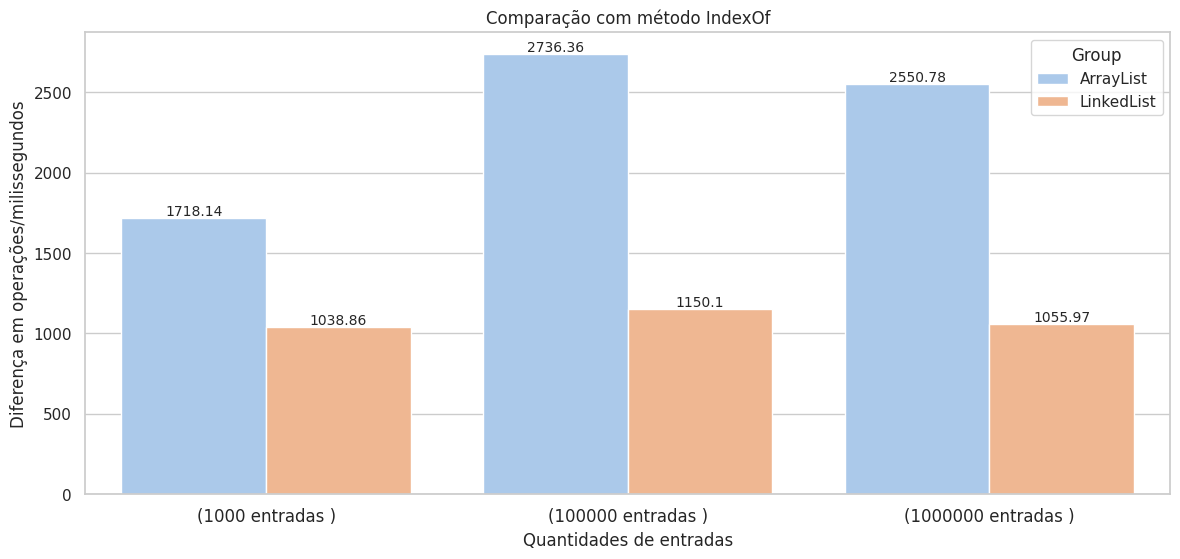

In [20]:
graph = sns.barplot(data=indexOf,x="XLabel",y=indexOf['Diff'],hue='Group', dodge=True, palette='pastel')

plt.title("Comparação com método IndexOf")

plt.xlabel("Quantidades de entradas")
plt.ylabel("Diferença em operações/milissegundos")

plt.yscale("linear")

for container in graph.containers:
    graph.bar_label(container,fontsize=10)
plt.xticks(rotation=0,fontsize=12)

### IndexOf
A partir do gráfico acima, percebemos que <b>ArrayLists</b> dominam, com uma grande margem em todas as quantidades de entradas, em relação as <b>LinkedLists</b>. Dentre alguns dos motivos que levam a esses resultados, temos:

1. Lógica das estruturas
2. Complexidade do método
3. Uso do CPU e memória

#### Lógica das Estruturas:
- Sabe-se que por <b>ArrayLists</b> serem listas implementadas em <i>arrays</i>, os elementos são armazenados conjuntamente na memória, o que garante o acesso destes em tempo constante <i>O(1)</i>.
- Por outro lado, <b>LinkedLists</b> são listas abstraidas de <i>nós encadeados</i>, em que cada nó faz referências com os elementos seguintes e anteriores. Com isso, deve-se percorrer a lista sequencialmente para encontrar e acessar um elementos, custando no pior caso <i>O(n)</i>

#### Complexidade do método:
- <b>ArrayList</b>: custo constante, pois tem um array na memória que é rapidamente acessado
- <b>LinkedList</b>: custo proporcional à entrada, pois tem ponteiros que são acessados sequencialmente de forma lenta

#### Uso de CPU e Memória:
- Os <b>ArraysLists</b> aproveitam-se da <i>locality of reference</i>, o que permite que o cache acelere a busca
- As <b>LinkedLists</b> sofrem com <i>cache misses</i>, devido a dispersão dos nós na memória.



## Pesquisas a parte
#### Locality of Reference:
É a tendência de um processador de acessar o(s) mesmo(s) bloco(s) de memória repetidas vezes em um curto intervalo de tempo. Existem dois tipos principais, a especial e a temporal, que por questões de foco às análises, não serão discutidos.

<i>Fonte:William., Stallings (2010). Computer organization and architecture : designing for performance</i>

### Analisando método removeFirst

<Figure size 1200x600 with 0 Axes>

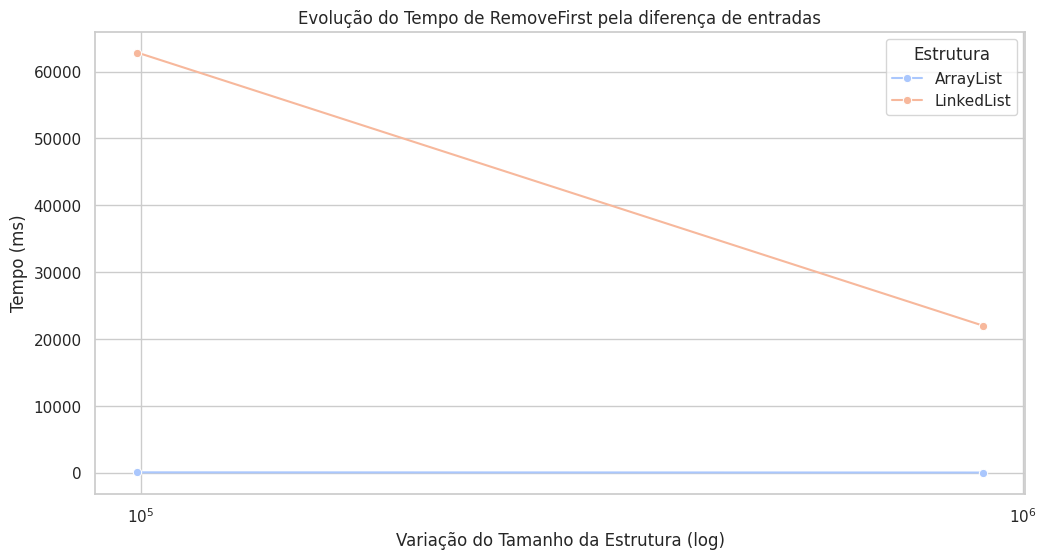

In [ ]:
remove_first_df = benchmarks[benchmarks["Methods"] == "RemoveFirst"]
remove_first_df['Estrutura'] = remove_first_df['BenchMark'].apply(lambda x: 'ArrayList' if 'Array' in x else 'LinkedList')
remove_first_df['Delta_Units'] = remove_first_df.groupby('Estrutura')['Units'].diff()

plt.figure(figsize=(12, 6))

plt.figure(figsize=(12, 6))
sns.lineplot(data=remove_first_df, x="Delta_Units", y="Diff", hue="Estrutura", marker="o", palette="coolwarm")
plt.xscale("log")
plt.title("Evolução do Tempo de RemoveFirst pela diferença de entradas")
plt.xlabel("Variação do Tamanho da Estrutura (log)")
plt.ylabel(" Operações/ms")
plt.legend(title="Estrutura")
plt.show()

![removeTests](../dados/TestesRemoves.png "Testes Remove")

## Métodos de remoção
### RemoveFirst

Tomando por base a plotagem feita com JMH Visualizer, podemos notar a alta performace que <b>LinkedLists</b> possuem para remover o primeiro elemento.

#### Por que isso ocorre?

- Pela diferença na estrutura de <b>LinkedLists</b> ser baseada em conjuntos de nós que se enderençam entre si, a removação do primeiro elemento iria implicar, apenas, na troca de constantes como: o segundo elemento apontar para <i>null</i> como seu anterior e este mesmo elemento passar a ser o <i>head</i> da lista.

- Por outro lado, <b>ArrayLists</b> não possuem essa capacidade por se basearem em <i>arrays</i>. Visando evitar a existência de "buracos" ao remover um elemento da estrutura base, os <b>ArrayLists</b> precisam realizar o deslocamento de elementos, que no pior caso seria <i>O(n)</i>, o qual é bem mais custoso como se percebe pelo gráfico.

#### Complexidade do Método

- ArrayList: O(n), devido ao deslocamento no pior caso
- LinkedLists: O(1), devido à manipulação de constantes

#### Interpretação gráfica

A maior disparidade está presente nas entradas iniciais (size = 1000), mas mesmo com o aumento exponencial das entradas, as remoções de LinkedLists são mais performáticas. Tomando como exemplo as entradas iniciais, vêmos que as LinkedList conseguem operar 4 vezes mais que os ArrayLists em 1 milissegundo, corroborando com a teoria citada anteriormente. Para as entradas seguintes, acredita-se que a falta de um melhor isolamento do ambiente seja a razão de inconsistências na quantidade de operações por milissegundos proporciais entre as estruturas.

### RemoveLast

Brevemente, podemos concluir que ambas as estruturas possuem performaces similares para esse método, mantendo uma proporção de operações por milissegundos equiparadas.

#### Por que isso acontece?

 - De maneira oposta ao RemoveFirst, para ambas as estruturas remover o último elemento da lista é uma operação constante, a qual ocorre: pela alteração da referência do final da lista e pelo rompimento do endereçamento do penúltimo elemento com o último elemento da lista em ArrayList e LinkedList, respectivamente. Assim, a não necessidade de reorganizar a lista em ArrayLists faz o mesmo ser tão rápido quanto LinkedLists para esse tipo de remoção. 